# 05 — The multimodal demo: fifteen techniques, one hidden number

The earlier notebooks use a small project with two techniques. This one uses
the **showcase**: a synthetic Cu–Au alloy nanocatalyst library for CO₂
electroreduction, characterised the way a real campaign would be.

Everything in it follows from **one hidden number per sample** — the gold
atomic fraction. Fifteen techniques see fifteen different shadows of it, and
the job of this notebook is to recover it from several of them independently
and check that they agree.

Why Cu–Au: the two metals are miscible at every composition, so the series is
a real material rather than a thought experiment, and three textbook
consequences are available at once — Vegard's law in the diffraction, a single
plasmon band that moves with composition, and a selectivity switch from
hydrocarbons on Cu to CO on Au.

> The physics is simplified. Peak positions, line energies and lattice
> parameters are real; self-absorption, drift and matrix effects are not
> there. The project exists to check the **pipeline**, not to validate an
> analysis.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from NanoOrganizer import open_project
from NanoOrganizer.demo import (
    build_showcase_project, demo_root, showcase_truth,
)
from NanoOrganizer.demo import materials as mat
from NanoOrganizer.viz import plots

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

ROOT = demo_root("Showcase")
build_showcase_project(ROOT)
wb = open_project(ROOT)
print(wb.summary())

Showcase: 9 samples, 144 measurements (144 readable here, 0 not mounted).
Modalities: uvvis, eds, xps, raman, ir, saxs1d, waxs1d, saxs2d, xas, xpcs_g2, dos, ec, dls, sem, tem, tomo
Root: /home/yuzhang/Repos/OrgDemo/Showcase


## 1. What came in, and what is missing

Two routes: most measurements are declared in `MetaData/*.py`, while TEM, SEM,
tomography and DLS arrive as `<Modality>Data/<SampleID>/` folders that nobody
wrote a record for.

The matrix is deliberately **sparse** — XAS, tomography, XPCS and the 2D
detector images are on a few samples, not all of them, because beamtime and
microscope time are finite. One synthesis failed and has no data at all.

In [2]:
report = wb.available()
print(f"{report['n_samples']} samples, {report['n_measurements']} measurements, "
      f"{report['n_unresolved']} unresolved")

coverage = pd.DataFrame(
    {m: {s.sample_id: len(s.get_measurements(modality=m)) for s in wb.project.samples.values()}
     for m in wb.project.modalities()}
).fillna(0).astype(int)
coverage

9 samples, 144 measurements, 0 unresolved


,uvvis,eds,xps,raman,ir,saxs1d,waxs1d,saxs2d,xas,xpcs_g2,dos,ec,dls,sem,tem,tomo
CuAu01,1,1,2,1,1,1,1,1,2,1,1,4,1,1,1,1
CuAu02,1,1,2,1,1,1,1,0,0,0,1,4,1,1,1,0
CuAu03,1,1,2,1,1,1,1,0,2,0,1,4,1,1,1,0
CuAu04,1,1,2,1,1,1,1,1,0,1,1,4,1,1,1,0
CuAu05,1,1,2,1,1,1,1,0,2,0,1,4,1,1,1,0
CuAu06,1,1,2,1,1,1,1,0,0,0,1,4,1,1,1,1
CuAu07,1,1,2,1,1,1,1,0,2,0,1,4,1,1,1,0
CuAu08,1,1,2,1,1,1,1,1,0,1,1,4,1,1,1,0
CuAu09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


The empty row is `CuAu09`, the aborted run. It is in the table on purpose:
a filter that silently drops it would hide the fact that it exists.

In [3]:
table = wb.table()
table[["sample_id", "synthesis.status", "synthesis.composition.nominal_x_Au",
       "testing.performance.FE_CO_pct", "testing.performance.j_CO_mA_cm2"]]

,sample_id,synthesis.status,synthesis.composition.nominal_x_Au,testing.performance.FE_CO_pct,testing.performance.j_CO_mA_cm2
sample_id,,,,,
CuAu01,CuAu01,done,0.00,2.3,0.77
CuAu02,CuAu02,done,0.10,5.4,1.71
CuAu03,CuAu03,done,0.25,17.9,5.02
CuAu04,CuAu04,done,0.40,44.0,10.74
CuAu05,CuAu05,done,0.55,70.1,14.58
CuAu06,CuAu06,done,0.70,82.6,14.21
CuAu07,CuAu07,done,0.85,86.6,11.77
CuAu08,CuAu08,done,1.00,87.6,8.76
CuAu09,CuAu09,error,0.50,NaN,NaN


## 2. Four groups, four kinds of plot

The viewer dispatches on **shape**, not technique, so the same four calls
cover everything in the project.

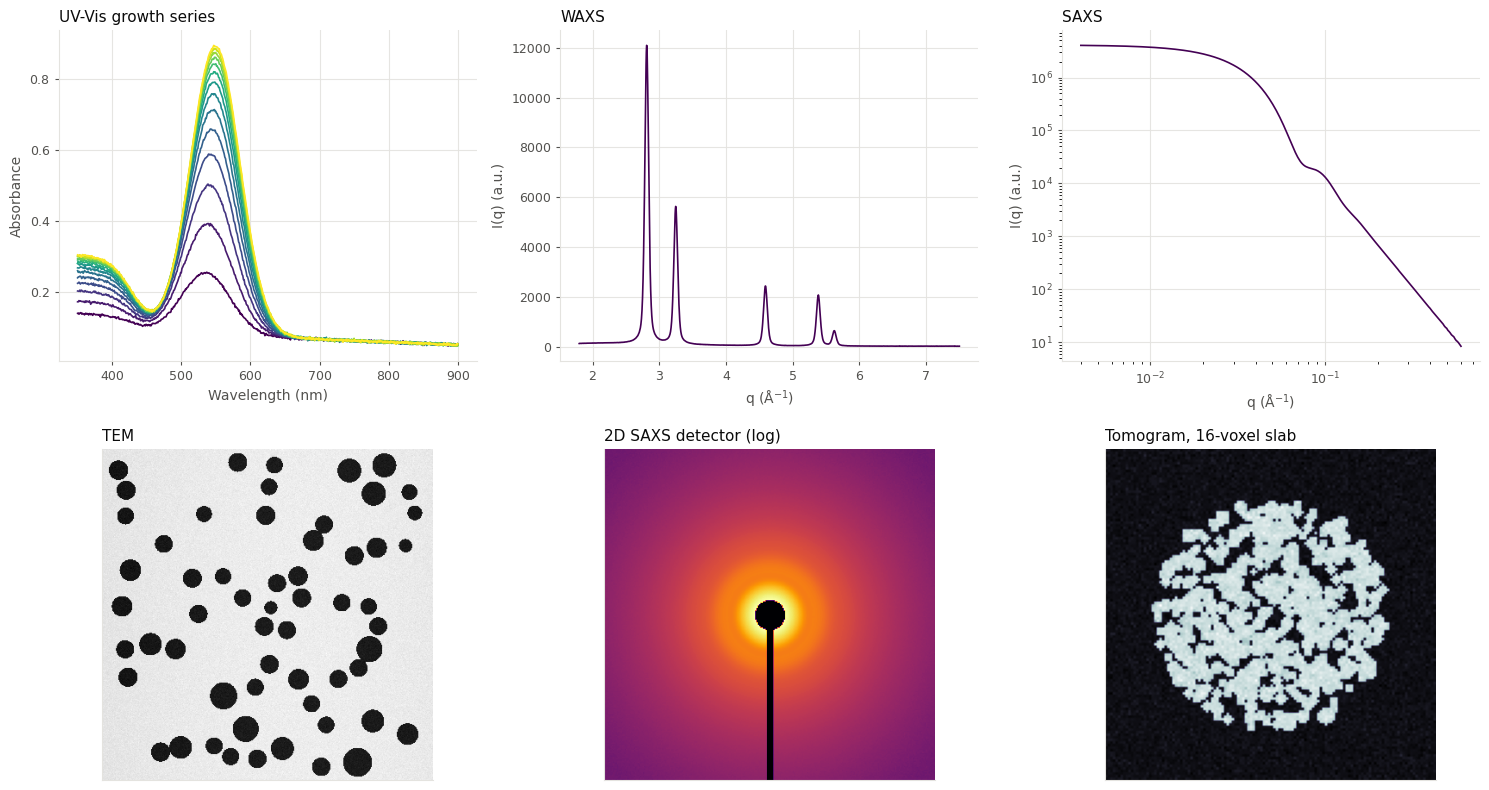

In [4]:
from NanoOrganizer.analysis.reading import load_curve_set, load_image, load_volume

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plots.style(axes[0, 0])

# --- curves ---------------------------------------------------------------
for ax, (modality, title, logx) in zip(
        axes[0], [("uvvis", "UV-Vis growth series", False),
                  ("waxs1d", "WAXS", False),
                  ("saxs1d", "SAXS", True)]):
    m = wb.measurement("CuAu05", modality=modality)
    x, Y, info = load_curve_set(m, wb.resolver)
    for i, y in enumerate(Y):
        ax.plot(x, y, lw=1.2, color=plt.cm.viridis(i / max(len(Y) - 1, 1)))
    if logx:
        ax.set_xscale("log"); ax.set_yscale("log")
    plots.style(ax, m.spec.x_label, m.spec.y_label, title)

# --- images and a volume ---------------------------------------------------
tem, _ = load_image(wb.measurement("CuAu05", modality="tem"), wb.resolver)
axes[1, 0].imshow(tem, cmap="gray"); plots.style(axes[1, 0], title="TEM")

det, _ = load_image(wb.measurement("CuAu01", modality="saxs2d"), wb.resolver)
axes[1, 1].imshow(np.log1p(det), cmap="inferno")
plots.style(axes[1, 1], title="2D SAXS detector (log)")

# A single slice through a packed cluster is mostly gaps; a thin slab
# projection is what actually gets looked at, and shows the pore network.
vol, _ = load_volume(wb.measurement("CuAu01", modality="tomo"), wb.resolver)
middle = vol.shape[0] // 2
axes[1, 2].imshow(vol[middle - 8:middle + 8].max(axis=0), cmap="bone")
plots.style(axes[1, 2], title="Tomogram, 16-voxel slab")

for ax in axes[1]:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

## 3. Three independent routes to the composition

This is the point of organising measurements together rather than per
instrument. Each of these is a different machine in a different room:

| technique | what it measures | how it gives composition |
|---|---|---|
| **EDS** | characteristic X-ray line intensities | Cliff–Lorimer ratio of Au Lα to Cu Kα |
| **WAXS** | the (111) lattice spacing | Vegard's law, run backwards |
| **UV-Vis** | the plasmon band position | it interpolates between Cu and Au |

`curve_metrics` does the EDS job — the area under a line, no model fitted —
and `peak_fit` does the other two.

In [5]:
_ = wb.batch("curve_metrics", modality="eds", prefix="eds_cu_", x_min=7.7, x_max=8.4)
_ = wb.batch("curve_metrics", modality="eds", prefix="eds_au_", x_min=9.4, x_max=10.0)

_ = wb.batch("peak_fit", modality="waxs1d", x_range=(2.5, 3.6),
         n_peaks=2, shape="pseudo_voigt", background="linear")
_ = wb.batch("peak_fit", modality="uvvis", x_range=(470.0, 800.0),
         reduce="last_decile", background="linear")

curve_metrics: 8/8 succeeded
curve_metrics: 8/8 succeeded
peak_fit: 8/8 succeeded


peak_fit: 8/8 succeeded


Three notes on those calls, each of which is a real decision:

* `prefix=` keeps the two EDS windows in two columns. Without it the second
  would overwrite the first.
* `background="linear"` matters. An EDS line sits on bremsstrahlung and a
  plasmon sits on an interband edge; fitting a flat background through a slope
  does not merely lower R², it drags the peak centre up the slope.
* `reduce="last_decile"` picks the **end** of the UV-Vis growth series. Fitting
  an early frame measures a particle that had not finished growing.

In [6]:
from NanoOrganizer.demo.signals import EDS_K_FACTOR_AU_CU

truth = showcase_truth().set_index("sample_id")
t = wb.table().set_index("sample_id").reindex(truth.index)

gold = t["derived.eds_au_area"] / EDS_K_FACTOR_AU_CU
x_eds = gold / (gold + t["derived.eds_cu_area"])

lattice = 2 * np.pi * np.sqrt(3) / t["derived.waxs1d_peak1_center"]
x_waxs = (lattice - mat.A_CU) / (mat.A_AU - mat.A_CU)

comparison = pd.DataFrame({
    "x_true": truth["x_Au"],
    "x_from_EDS": x_eds,
    "x_from_WAXS": x_waxs,
    "lspr_fit_nm": t["derived.uvvis_peak1_center"],
    "lspr_true_nm": truth["true_lspr_nm"],
})
comparison.round(3)

,x_true,x_from_EDS,x_from_WAXS,lspr_fit_nm,lspr_true_nm
sample_id,,,,,
CuAu01,0.00,-0.002,0.00,579.350,580.00
CuAu02,0.10,0.097,0.10,574.412,575.08
CuAu03,0.25,0.234,0.25,566.577,567.25
CuAu04,0.40,0.381,0.40,558.177,558.88
CuAu05,0.55,0.529,0.55,549.231,549.97
CuAu06,0.70,0.687,0.70,539.693,540.52
CuAu07,0.85,0.841,0.85,529.602,530.53
CuAu08,1.00,0.999,1.00,519.049,520.00


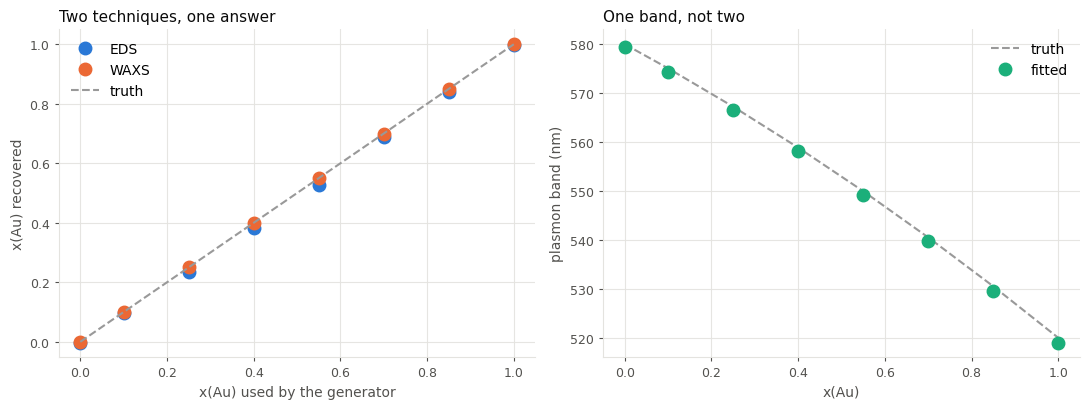

In [7]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.2))

for name, values, colour in (("EDS", x_eds, plots.CATEGORICAL[0]),
                             ("WAXS", x_waxs, plots.CATEGORICAL[1])):
    left.plot(truth["x_Au"], values, "o", ms=9, color=colour, label=name)
left.plot([0, 1], [0, 1], "--", color="0.6", lw=1.5, label="truth")
plots.style(left, "x(Au) used by the generator", "x(Au) recovered",
            "Two techniques, one answer")
left.legend(frameon=False)

right.plot(truth["x_Au"], truth["true_lspr_nm"], "--", color="0.6",
           lw=1.5, label="truth")
right.plot(truth["x_Au"], t["derived.uvvis_peak1_center"], "o", ms=9,
           color=plots.CATEGORICAL[2], label="fitted")
plots.style(right, "x(Au)", "plasmon band (nm)", "One band, not two")
right.legend(frameon=False)
fig.tight_layout()

A single band moving smoothly is the evidence that these are **alloy**
particles. A physical mixture of copper particles and gold particles would
show two bands whose positions never move and whose relative heights change
instead — worth remembering the next time a real sample does that.

## 4. Where techniques disagree, and why that is information

Two disagreements are built into the project on purpose.

**TEM vs DLS vs SEM.** TEM resolves primary particles. DLS reports the
hydrated, ligand-wrapped object and weights it by scattered intensity, which
goes as the sixth power of diameter — so it reads larger. SEM at this
magnification resolves the *agglomerates*, not the primaries at all.

**EDS vs XPS.** EDS samples the whole particle; XPS samples the top few
nanometres. Gold has the lower surface energy and segregates outwards, so the
surface is richer in gold than the bulk. The gap between them is the
segregation.

particle_sizing: 8/8 succeeded


particle_sizing: 8/8 succeeded
curve_metrics: 8/8 succeeded
curve_metrics: 8/8 succeeded
curve_metrics: 8/8 succeeded


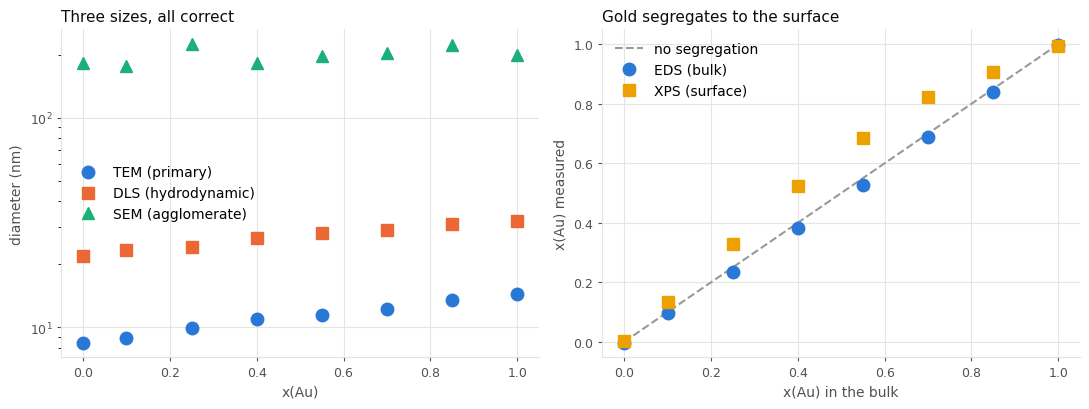

In [8]:
wb.batch("particle_sizing", modality="tem")
wb.batch("particle_sizing", modality="sem", max_diameter_nm=500, min_circularity=0.5)
wb.batch("curve_metrics", modality="dls", x_min=5, x_max=120)
wb.batch("curve_metrics", modality="xps", role="cu2p", prefix="xps_cu_", x_min=929, x_max=937)
wb.batch("curve_metrics", modality="xps", role="au4f", prefix="xps_au_", x_min=81.5, x_max=86.0)

from NanoOrganizer.demo.signals import XPS_RSF
t = wb.table().set_index("sample_id").reindex(truth.index)
surface_au = t["derived.xps_au_area"] / XPS_RSF["Au 4f7/2"]
surface_cu = t["derived.xps_cu_area"] / XPS_RSF["Cu 2p3/2"]
x_xps = surface_au / (surface_au + surface_cu)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.2))
left.plot(truth["x_Au"], t["derived.tem_d_mean"], "o", ms=9,
          color=plots.CATEGORICAL[0], label="TEM (primary)")
left.plot(truth["x_Au"], t["derived.dls_x_at_max"], "s", ms=9,
          color=plots.CATEGORICAL[1], label="DLS (hydrodynamic)")
left.plot(truth["x_Au"], t["derived.sem_d_mean"], "^", ms=9,
          color=plots.CATEGORICAL[2], label="SEM (agglomerate)")
left.set_yscale("log")
plots.style(left, "x(Au)", "diameter (nm)", "Three sizes, all correct")
left.legend(frameon=False)

right.plot([0, 1], [0, 1], "--", color="0.6", lw=1.5, label="no segregation")
right.plot(truth["x_Au"], x_eds, "o", ms=9, color=plots.CATEGORICAL[0],
           label="EDS (bulk)")
right.plot(truth["x_Au"], x_xps, "s", ms=9, color=plots.CATEGORICAL[3],
           label="XPS (surface)")
plots.style(right, "x(Au) in the bulk", "x(Au) measured",
            "Gold segregates to the surface")
right.legend(frameon=False)
fig.tight_layout()

## 5. The structure–property chain

The payoff. Three links, each measured by a different technique:

1. **DFT** gives the d-band centre of the surface — the centroid of the
   projected density of states.
2. That sets how strongly the surface binds **CO**, which the IR spectrum sees
   directly as the frequency of the adsorbed C–O stretch.
3. That sets the **selectivity**: CO binding too weak and it desorbs before
   anything can happen to it, too strong and it never leaves.

So the CO partial current should be a **volcano** in the binding energy. It is
the Sabatier principle, and it is the reason anyone builds a composition
series in the first place.

In [9]:
wb.batch("curve_metrics", modality="dos", x_min=-8.0, x_max=0.5)
wb.batch("peak_fit", modality="ir", x_range=(2020.0, 2180.0), background="linear")

t = wb.table().set_index("sample_id").reindex(truth.index)
chain = pd.DataFrame({
    "x_Au": truth["x_Au"],
    "d_band_eV": t["derived.dos_x_centroid"],
    "d_band_true": truth["true_d_band_eV"],
    "E_ads_CO_eV": t["computation.descriptors.E_ads_CO_eV"],
    "CO_stretch_cm-1": t["derived.ir_peak1_center"],
    "FE_CO_pct": t["testing.performance.FE_CO_pct"],
    "j_CO": t["testing.performance.j_CO_mA_cm2"],
})
chain.round(3)

curve_metrics: 8/8 succeeded
peak_fit: 7/8 succeeded; failures: fit quality R² = 0.8352 is below the 0.9 floor


,x_Au,d_band_eV,d_band_true,E_ads_CO_eV,CO_stretch_cm-1,FE_CO_pct,j_CO
sample_id,,,,,,,
CuAu01,0.00,-2.745,-2.670,-0.620,NaN,2.3,0.77
CuAu02,0.10,-2.843,-2.759,-0.594,2094.068,5.4,1.71
CuAu03,0.25,-2.991,-2.892,-0.555,2097.100,17.9,5.02
CuAu04,0.40,-3.139,-3.026,-0.516,2100.001,44.0,10.74
CuAu05,0.55,-3.282,-3.160,-0.477,2103.018,70.1,14.58
CuAu06,0.70,-3.417,-3.293,-0.438,2106.013,82.6,14.21
CuAu07,0.85,-3.539,-3.426,-0.399,2108.985,86.6,11.77
CuAu08,1.00,-3.648,-3.560,-0.360,2112.010,87.6,8.76


Two honest notes on that table.

The fitted d-band centre sits about 0.1 eV below the generator's value. That
is not noise — it is the **integration window**: the band has tails outside
`(-8, 0.5)` eV and cutting them off moves the centre of mass. A d-band centre
is only defined together with the window it was integrated over, and quoting
one without the other is a common way for two papers to disagree about
nothing.

`CO_stretch` is missing for `CuAu01`. Pure copper makes almost no CO, so there
is almost no band to fit, and `peak_fit` refused rather than returning a
centre fitted to noise. A missing value here is the correct answer.

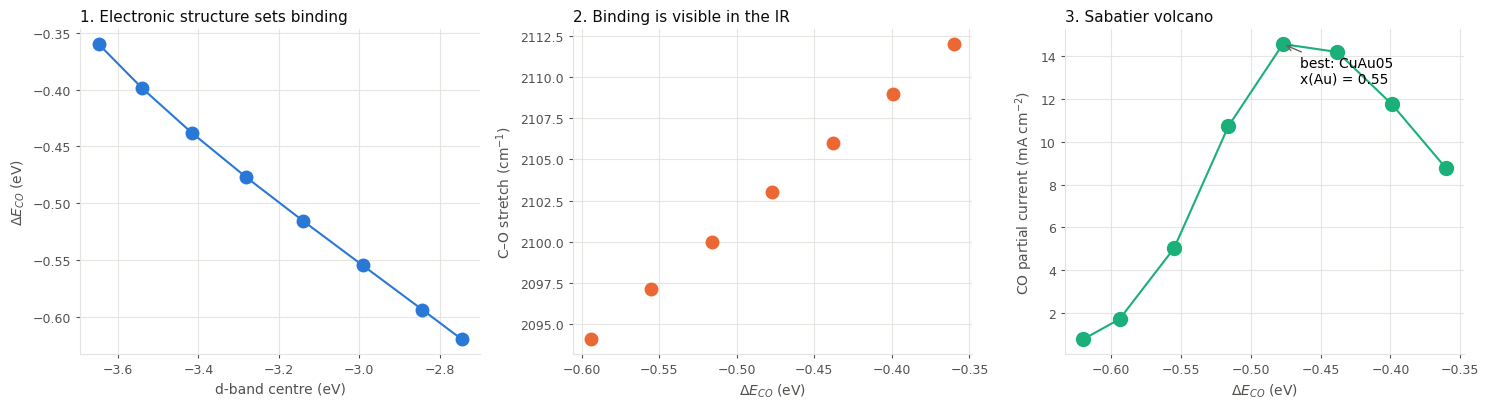

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(chain["d_band_eV"], chain["E_ads_CO_eV"], "o-", ms=9,
             color=plots.CATEGORICAL[0])
plots.style(axes[0], "d-band centre (eV)", r"$\Delta E_{CO}$ (eV)",
            "1. Electronic structure sets binding")

axes[1].plot(chain["E_ads_CO_eV"], chain["CO_stretch_cm-1"], "o", ms=9,
             color=plots.CATEGORICAL[1])
plots.style(axes[1], r"$\Delta E_{CO}$ (eV)", "C–O stretch (cm$^{-1}$)",
            "2. Binding is visible in the IR")

order = chain["E_ads_CO_eV"].argsort()
axes[2].plot(chain["E_ads_CO_eV"].iloc[order], chain["j_CO"].iloc[order],
             "o-", ms=10, color=plots.CATEGORICAL[2])
peak = chain["j_CO"].idxmax()
axes[2].annotate(f"best: {peak}\nx(Au) = {chain.loc[peak, 'x_Au']:.2f}",
                 xy=(chain.loc[peak, "E_ads_CO_eV"], chain.loc[peak, "j_CO"]),
                 xytext=(12, -28), textcoords="offset points", fontsize=10,
                 arrowprops=dict(arrowstyle="->", color="0.4"))
plots.style(axes[2], r"$\Delta E_{CO}$ (eV)", "CO partial current (mA cm$^{-2}$)",
            "3. Sabatier volcano")
fig.tight_layout()

## 6. The measurement behind the summary

The numbers above came from the authored `testing.performance` block — what
would be typed into a lab notebook. The underlying data is there too: one file
per product, so the selectivity switch can be read off directly.

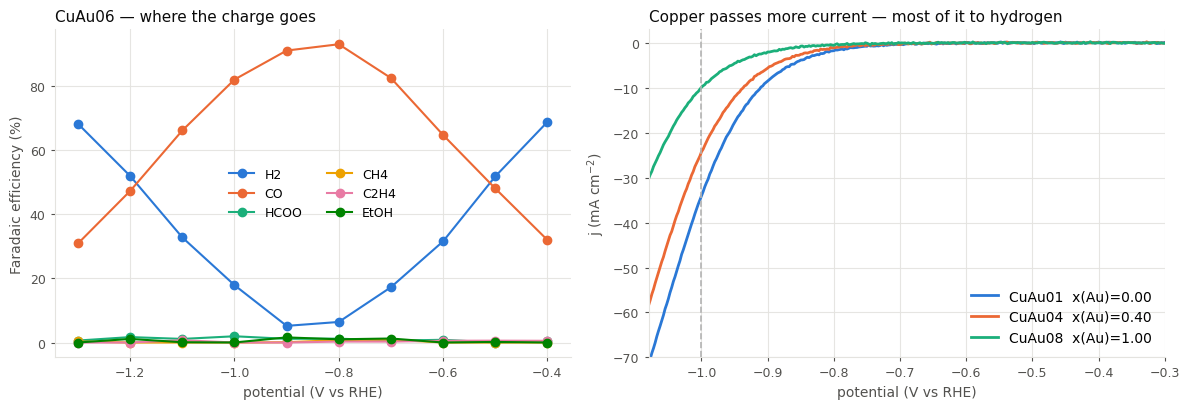

In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.2))

m = wb.measurement("CuAu06", modality="ec", role="co2-rr-fe")
potential, efficiencies, info = load_curve_set(m, wb.resolver)
for label, values, colour in zip(info["labels"], efficiencies, plots.CATEGORICAL):
    left.plot(potential, values, "o-", ms=6, color=colour,
              label=label.replace("FE_", "").replace(".dat", ""))
plots.style(left, "potential (V vs RHE)", "Faradaic efficiency (%)",
            "CuAu06 — where the charge goes")
left.legend(frameon=False, ncol=2, fontsize=9)

for sample_id, colour in zip(["CuAu01", "CuAu04", "CuAu08"], plots.CATEGORICAL):
    m = wb.measurement(sample_id, modality="ec", role="co2-rr")
    x, Y, _ = load_curve_set(m, wb.resolver)
    x_au = truth.loc[sample_id, "x_Au"]
    right.plot(x, Y[0], color=colour, lw=2, label=f"{sample_id}  x(Au)={x_au:.2f}")
# Past about -1.1 V every sample is pinned at the CO2 mass-transport limit of
# the gas-diffusion electrode, so the composition difference is only visible
# before the curves merge. The dashed line is where the summary was reported.
right.axvline(-1.0, color="0.7", ls="--", lw=1.2)
right.set_xlim(-1.08, -0.3)
right.set_ylim(-70, 3)
plots.style(right, "potential (V vs RHE)", "j (mA cm$^{-2}$)",
            "Copper passes more current — most of it to hydrogen")
right.legend(frameon=False, loc="lower right")
fig.tight_layout()

## 7. Not every technique has a story

Oxygen evolution was measured on every sample. The trend is weak and the
material is a mediocre OER catalyst at either end of the series.

That is in the demo deliberately. A worked example where every measurement
lines up teaches a falsehood about real campaigns — and the habit worth having
is to look at the spread before reading a trend into it.

curve_metrics: 8/8 succeeded
spread across the series: 60 mV


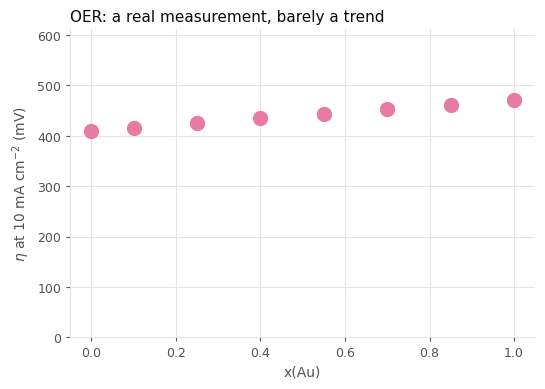

In [12]:
wb.batch("curve_metrics", modality="ec", role="oer", prefix="oer_",
         threshold=10.0, subtract_baseline=False)
t = wb.table().set_index("sample_id").reindex(truth.index)
overpotential_mV = (t["derived.oer_x_at_threshold"] - 1.23) * 1000

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(truth["x_Au"], overpotential_mV, "o", ms=10, color=plots.CATEGORICAL[4])
ax.set_ylim(0, 1.3 * overpotential_mV.max())
plots.style(ax, "x(Au)", r"$\eta$ at 10 mA cm$^{-2}$ (mV)",
            "OER: a real measurement, barely a trend")
print(f"spread across the series: {overpotential_mV.max() - overpotential_mV.min():.0f} mV")

## 8. Everything stays filterable

Each batch wrote its scalars back as `derived.*` columns, so the loop closes:
**filter → analyse → new columns → filter again**. Save when you are happy
with the table.

In [13]:
derived = [c for c in wb.table().columns if c.startswith("derived.")]
print(f"{len(derived)} derived columns now exist, for example:")
for name in derived[:12]:
    print("  ", name)

best = wb.table().query("`derived.tem_d_mean` < 12 and `testing.performance.FE_CO_pct` > 40")
print(f"\nsmall particles that are also CO-selective: {list(best['sample_id'])}")

# wb.save()   # writes .nanoorganizer/ in the project folder

107 derived columns now exist, for example:
   derived.eds_cu_y_max
   derived.eds_cu_x_at_max
   derived.eds_cu_y_at_max_raw
   derived.eds_cu_y_min
   derived.eds_cu_area
   derived.eds_cu_x_centroid
   derived.eds_cu_y_mean
   derived.eds_au_y_max
   derived.eds_au_x_at_max
   derived.eds_au_y_at_max_raw
   derived.eds_au_y_min
   derived.eds_au_area

small particles that are also CO-selective: ['CuAu04', 'CuAu05']


## 9. Turning the tomogram around

A projection tells you what is in there; only rotation tells you what shape it
is. `NanoOrganizer.viz.interactive` builds Plotly figures, so the same call
works here, in the web app, and written out to a standalone HTML file.

Four ways to look at a volume — start with `isosurface`, and move the
threshold before believing any of it, because that one number decides what the
structure appears to be.

In [14]:
from NanoOrganizer.viz import interactive as iv

volume, _ = load_volume(wb.measurement("CuAu01", modality="tomo"), wb.resolver)

figure = iv.volume_figure(
    volume, mode="isosurface", level=130, voxel_size=2.0, unit="nm",
    colorscale="Viridis", opacity=0.9, title="CuAu01 tomogram",
)
figure.show()      # drag to rotate · scroll to zoom · double-click to reset

Three other modes are worth knowing:

```python
iv.volume_figure(volume, mode="volume")    # translucent — shows the interior
iv.volume_figure(volume, mode="points")    # one marker per voxel; most responsive
iv.volume_figure(volume, mode="slices",    # three planes you can position
                 slice_fractions=(0.3, 0.5, 0.7))
```

A large volume is strided down before it is rendered, and the figure title
says by how much. That is not politeness: a browser does not slow down
gracefully on a 128³ translucent volume, it locks the tab.

The 1D and 2D figures have interactive versions too — `iv.curves_figure` and
`iv.image_figure` — with the same styling arguments the matplotlib ones take.

In [15]:
potential, efficiencies, info = load_curve_set(
    wb.measurement("CuAu06", modality="ec", role="co2-rr-fe"), wb.resolver)

iv.curves_figure(
    [(label.replace("FE_", "").replace(".dat", ""), potential, values)
     for label, values in zip(info["labels"], efficiencies)],
    xlabel="potential (V vs RHE)", ylabel="Faradaic efficiency (%)",
    title="CuAu06 — hover for the exact number", marker="circle",
    legend_position="top left", height=430,
).show()

## 10. What is actually in the folder

Before organising a dataset you have to understand its shape. `structure.tree`
walks anything — a directory, a JSON file, an HDF5 group, an `.npz`, a Python
metadata module — and shows one layer at a time.

It reads **structure, not data**: array shapes come from file headers, so a
4 GB tomogram is described without being opened.

In [16]:
from NanoOrganizer import structure

print(structure.tree(ROOT, depth=2, limit=4))

📁 Showcase  11 folders · 1 file · .txt 1 · 1 hidden
├── 📁 Computation  8 folders
│   ├── 📁 CuAu01  1 file · .dat 1
│   ├── 📁 CuAu02  1 file · .dat 1
│   ├── 📁 CuAu03  1 file · .dat 1
│   ├── 📁 CuAu04  1 file · .dat 1
│   └── … +4 more  raise the per-layer limit to see them
├── 📁 DLSData  8 folders
│   ├── 📁 CuAu01  1 file · .dat 1
│   ├── 📁 CuAu02  1 file · .dat 1
│   ├── 📁 CuAu03  1 file · .dat 1
│   ├── 📁 CuAu04  1 file · .dat 1
│   └── … +4 more  raise the per-layer limit to see them
├── 📁 Dynamics  3 folders
│   ├── 📁 CuAu01  1 file · .dat 1
│   ├── 📁 CuAu04  1 file · .dat 1
│   └── 📁 CuAu08  1 file · .dat 1
├── 📁 Electrochemistry  8 folders
│   ├── 📁 CuAu01  9 files · .dat 9
│   ├── 📁 CuAu02  9 files · .dat 9
│   ├── 📁 CuAu03  9 files · .dat 9
│   ├── 📁 CuAu04  9 files · .dat 9
│   └── … +4 more  raise the per-layer limit to see them
└── … +8 more  raise the per-layer limit to see them


The same walk descends *into* files, which is the part `ls` cannot do.
An address is a path, optionally followed by `::` and a path inside the file —
`run.h5::entry/instrument`, `record.json::project/samples/0`.

In [17]:
print(structure.tree(f"{ROOT}/MetaData/Characterization_dict.py",
                     depth=3, limit=4))

📄 Characterization_dict.py  37.8 KB
└── 🔑 Characterization_dict  8 samples
    ├── 🔑 CuAu01  14 keys
    │   ├── · sample_id  str = CuAu01
    │   ├── 🔑 characterization_batch  5 keys
    │   ├── 🔑 UVVis  7 keys
    │   ├── 🔑 EDS  7 keys
    │   └── … +10 more  raise the per-layer limit to see them
    ├── 🔑 CuAu02  10 keys
    │   ├── · sample_id  str = CuAu02
    │   ├── 🔑 characterization_batch  5 keys
    │   ├── 🔑 UVVis  7 keys
    │   ├── 🔑 EDS  7 keys
    │   └── … +6 more  raise the per-layer limit to see them
    ├── 🔑 CuAu03  12 keys
    │   ├── · sample_id  str = CuAu03
    │   ├── 🔑 characterization_batch  5 keys
    │   ├── 🔑 UVVis  7 keys
    │   ├── 🔑 EDS  7 keys
    │   └── … +8 more  raise the per-layer limit to see them
    ├── 🔑 CuAu04  12 keys
    │   ├── · sample_id  str = CuAu04
    │   ├── 🔑 characterization_batch  5 keys
    │   ├── 🔑 UVVis  7 keys
    │   ├── 🔑 EDS  7 keys
    │   └── … +8 more  raise the per-layer limit to see them
    └── … +4 more  raise the

`structure.children(address)` returns that layer as objects when you want to
walk it in code rather than read it. The **🌳 Structure** page in the web app
is the same thing with buttons: click a folder, see what is in it, click
again, and the breadcrumb keeps every ancestor one click away.

---

### Where to go next

* **The web app** — `viz`, then *Project → Generate an example one*. The same
  `Workbench` object, the same results.
* **Your own data** — the only thing the showcase has that your project does
  not is a `MetaData/*.py` file. Write one dict per stage, keyed by sample id,
  and put a glob or a file list in any block that names data. See
  `docs/sample_model.md`.
* **Your own technique** — one `register()` in `core/modality.py`. No page and
  no notebook changes.